In [1]:
import torch
import matplotlib.pyplot as plt

#### Automatic Differentiation With torch.autograd
<li>
    <ol><b>Forward Propagation</b> 
        <li>
            <ol>Computes the model's output by passing the input data through the network layers.</ol>
        </li>
    </ol>
    <ol><b>Backward Propagation</b>
        <li>
            <ol>Calculate the gradients of the loss with respect to the model's parameters using the chain rule, enabling parameter updates to minimize the loss.</ol>
        </li>
    </ol>
    
</li>

In [4]:
#Create tensors with requires grad = True
x = torch.tensor([2.0, 5.0], requires_grad=True)
y = torch.tensor([3.0, 7.0], requires_grad=True)

z = (x * y) + (y**2)

z.retain_grad() #by default 

#Compute the gradient
z_sum = z.sum().backward()

print(f"Gradient of x : {x.grad}")
print(f"Gradient of y : {y.grad}")
print(f"Gradient of z : {z.grad}")
print(f"Result of the operation: z = {z.detach()}")

Gradient of x : tensor([3., 7.])
Gradient of y : tensor([ 8., 19.])
Gradient of z : tensor([1., 1.])
Result of the operation: z = tensor([15., 84.])


#### Detaching tensor from Computation Graph

The <b>detach()</b> method is used to create a new tensor that shares storage with the original tensor but without tracking operations. When you can detach(), it return a new tensor that does not require 

In [6]:
print("Before detaching z from the computatioal graph: ", z.requires_grad)
z_det = z.detach()
print("After detaching z from the computational graph: ", z_det.requires_grad)

Before detaching z from the computatioal graph:  True
After detaching z from the computational graph:  False


In [12]:
from torchviz import make_dot

dot = make_dot(z, params={"x": x, "y": y, "z": z})
dot.render("./images/module_2/Gradcomputationgraph", format="png")

'images/module_2/Gradcomputationgraph.png'

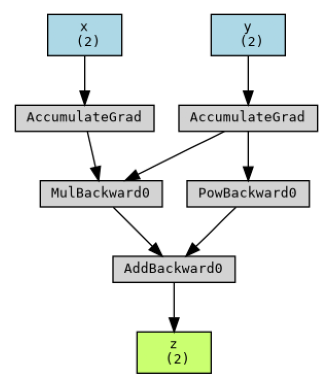

In [13]:
img = plt.imread("./images/module_2/Gradcomputationgraph.png")
plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
Y = torch.tensor([1.0,], requires_grad=True)
with torch.no_grad():
	new_tensor = Y*2
	print(new_tensor.requires_grad, Y.requires_grad)

False True
